# Meat Consumption Around the World: Trends and Differences Across Continents

**A project that does a comparative analysis of meat consumption across continents**

💡<u>**How does meat consumption differ across continents, and how has it changed over time?**</u>

 **Hypotheses**

- H1 — Meat consumption per capita differs significantly between continents. (check)

- H2 — North America has a higher per-capita meat consumption than Africa and Asia. (check)

- H3 — Meat consumption has increased over time in Asia. (check)

- H4 — Poultry consumption has increased over time across most continents.

- H5 — Global meat consumption has increased over the period analyzed. (check)

In [11]:
import pandas as pd
import requests

**Data to Collect**

- <u>Dataset</u>

In [12]:
# Fetch the data.
total_consumption = pd.read_csv("https://ourworldindata.org/grapher/per-capita-meat-type.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

total_consumption[total_consumption["code"].isin(["OWID_WRL"])]

total_consumption = total_consumption.rename(columns={
    "meat__poultry__00002734__food_available_for_consumption__0645pc__kilograms_per_year_per_capita": "poultry",
    "meat__beef_and_buffalo__00002731__food_available_for_consumption__0645pc__kilograms_per_year_per_capita": "beef_and_buffalo",
    "meat__sheep_and_goat__00002732__food_available_for_consumption__0645pc__kilograms_per_year_per_capita": "sheep_and_goat",
    "meat__pig__00002733__food_available_for_consumption__0645pc__kilograms_per_year_per_capita": "pig",
    "meat__other__00002735__food_available_for_consumption__0645pc__kilograms_per_year_per_capita": "other"
})

total_consumption.columns

Index(['entity', 'code', 'year', 'poultry', 'beef_and_buffalo',
       'sheep_and_goat', 'pig', 'other',
       'fish_and_seafood__00002960__food_available_for_consumption__0645pc__kilograms_per_year_per_capita'],
      dtype='str')

In [13]:
continents = [
    "OWID_AFR", "OWID_ASI", "OWID_EUR",
    "OWID_NAM", "OWID_SAM", "OWID_OCE"
]

meat_columns = [
    "poultry",
    "beef_and_buffalo",
    "sheep_and_goat",
    "pig",
    "other"
]

data = total_consumption[
    total_consumption["code"].isin(continents)
].copy()

data["Total"] = data[meat_columns].sum(axis=1)

change = (
    data
    .groupby("code")["Total"]
    .agg(["first", "last"])
)

change["percentage_change"] = (
    (change["last"] - change["first"]) / change["first"]
) * 100

change.sort_values("percentage_change", ascending=False).round(2)

,first,last,percentage_change
code,,,
OWID_ASI,5.37,37.15,591.31
OWID_SAM,38.74,87.92,126.97
OWID_EUR,47.22,78.63,66.54
OWID_NAM,72.93,100.80,38.21
OWID_AFR,13.48,16.67,23.64
OWID_OCE,99.46,95.14,-4.34


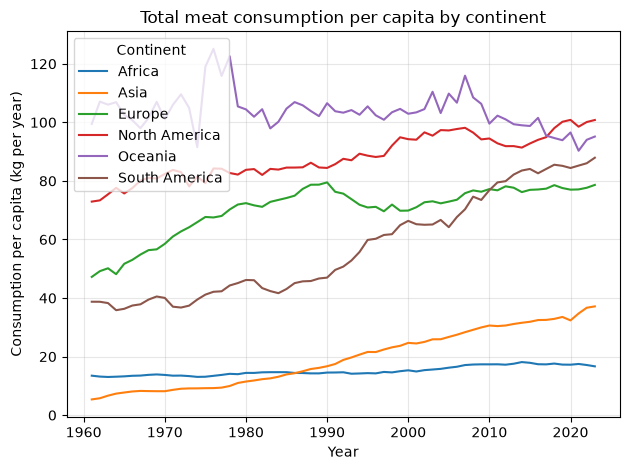

In [14]:
import matplotlib.pyplot as plt

continents = {
    "OWID_AFR": "Africa",
    "OWID_ASI": "Asia",
    "OWID_EUR": "Europe",
    "OWID_NAM": "North America",
    "OWID_SAM": "South America",
    "OWID_OCE": "Oceania",
}

continent_data = total_consumption[
    total_consumption["code"].isin(continents)
].copy()
continent_data["total_meat_per_capita"] = continent_data[meat_columns].sum(axis=1)
continent_data = continent_data.sort_values(["code", "year"])

for code, group in continent_data.groupby("code"):
    plt.plot(
        group["year"],
        group["total_meat_per_capita"],
        label=continents[code],
    )

plt.title("Total meat consumption per capita by continent")
plt.xlabel("Year")
plt.ylabel("Consumption per capita (kg per year)")
plt.legend(title="Continent")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
continents = [
    "OWID_AFR", "OWID_ASI", "OWID_EUR",
    "OWID_NAM", "OWID_SAM", "OWID_OCE"
]

poultry_column = "poultry"

poultry = total_consumption[
    total_consumption["code"].isin(continents)
][["code", "year", poultry_column]].copy()

poultry = poultry.sort_values(["code", "year"])

poultry.head()

poultry_change = (
    poultry
    .groupby("code")[poultry_column]
    .agg(["first", "last"])
)

poultry_change["percentage_change"] = (
    (poultry_change["last"] - poultry_change["first"])
    / poultry_change["first"]
) * 100

poultry_change.round(2)

,first,last,percentage_change
code,,,
OWID_AFR,1.31,7.02,434.86
OWID_ASI,0.88,12.71,1341.34
OWID_EUR,4.58,27.24,494.91
OWID_NAM,13.19,46.93,255.88
OWID_OCE,4.18,37.56,799.73
OWID_SAM,2.07,41.94,1924.62


In [16]:
total_consumption["total_meat_per_capita"] = total_consumption[meat_columns].sum(axis=1)
total_consumption.groupby("code")["total_meat_per_capita"].mean()


code
AFG    15.151546
AGO    15.279108
ALB    27.507875
ANT    92.957698
ARE    65.050876
         ...    
WSM    62.929771
YEM    11.525960
ZAF    42.453601
ZMB    15.057027
ZWE    23.050723
Name: total_meat_per_capita, Length: 210, dtype: float64

- <u>API</u>

In [17]:

def fetch_meat_data():
    
    url = "https://ourworldindata.org/grapher/per-capita-meat-type.csv"
    
    params = {
        "csvType": "filtered",
        "country": "OWID_AFR~OWID_ASI~OWID_EUR~OWID_NAM~OWID_OCE~OWID_SAM~PRT~USA"
    }
    
    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        
        data = pd.read_csv(
            pd.io.common.StringIO(response.text)
        )
        
        return data
    
    except requests.exceptions.RequestException as error:
        print(f"Error fetching data: {error}")
        return None

meat_api = fetch_meat_data()

continents = [
    "OWID_AFR", "OWID_EUR", "OWID_ASI",
    "OWID_NAM", "OWID_SAM", "OWID_OCE"
]

meat_columns = [
    "Poultry", "Beef and buffalo", "Sheep and goat",
    "Pork", "Other meats"
]

latest_year = meat_api["Year"].max()

total = (
    meat_api[
        (meat_api["Code"].isin(continents)) &
        (meat_api["Year"] == latest_year)
    ][["Code"] + meat_columns]
    .copy()
)

total["Total"] = total[meat_columns].sum(axis=1)

total = total.sort_values("Total", ascending=False)

total.round(2)

,Code,Poultry,Beef and buffalo,Sheep and goat,Pork,Other meats,Total
3,OWID_NAM,46.93,27.94,0.63,24.65,0.65,100.80
4,OWID_OCE,37.56,18.56,8.36,19.98,10.67,95.14
6,OWID_SAM,41.94,29.72,0.69,14.96,0.60,87.92
2,OWID_EUR,27.24,13.45,1.59,34.83,1.53,78.63
1,OWID_ASI,12.71,5.80,2.81,15.40,0.42,37.15
0,OWID_AFR,7.02,4.70,1.89,1.76,1.30,16.67


In [18]:
latest = meat_api[
    (meat_api["Code"].isin(continents)) &
    (meat_api["Year"] == latest_year)
].set_index("Code")[meat_columns]

latest["Predominant"] = latest.idxmax(axis=1)

latest[["Predominant"]]

,Predominant
Code,
OWID_AFR,Poultry
OWID_ASI,Pork
OWID_EUR,Pork
OWID_NAM,Poultry
OWID_OCE,Poultry
OWID_SAM,Poultry


- <u>Web Scraping</u>

## Conclusions

1. Differences Between Continents:

- Which continent consumes the most meat?

    - North America

- Which continent consumes the least?

    - Africa

- Which types of meat predominate in each region?

    - Africa — Fish and seafood
    - North America — Poultry
    - South America — Poultry
    - Europe — Pork
    - Asia — Pork
    - Oceania — Poultry


2. Temporal Evolution

- Has meat consumption increased or decreased over time?

    - Increased.


- Quais continentes tiveram as maiores mudanças?

    - Asia and South America


- Meat consumption per capita differs significantly between continents (H1 confirmed)

- North America has a higher per-capita meat consumption than Africa and Asia (H2 confirmed)

- Meat consumption has increased over time in Asia (H3 confirmed)

- Poultry consumption has increased over time across most continents (H4 confirmed)

- Global meat consumption has increased over the period analyzed (H5 confirmed)